<a href="https://colab.research.google.com/github/nicolenelson10/credit-card-fraud-detection-ml/blob/feature%2Ffinal-project/FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning-Based Credit Card Fraud Detection

## Evaluating Model Performance Under Class Imbalance

This project uses Machine Learning to detect fraudulent credit card transactions.

Two classification models are trained and compared:

1. Logistic Regression
2. Random Forest

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

The main objective is to understand model performance under severe class imbalance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

print("Dataset uploaded successfully!")

Saving archive.zip to archive.zip
Dataset uploaded successfully!


In [3]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")
print(os.listdir("dataset"))

Dataset extracted successfully!
['creditcard.csv']


In [4]:
df = pd.read_csv("dataset/creditcard.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (284807, 31)


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
print("Missing values:")
print(df.isnull().sum().sum())

Missing values:
0


In [8]:
print("Class Distribution:")
print(df["Class"].value_counts())

print("\nClass Distribution in Percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Distribution in Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


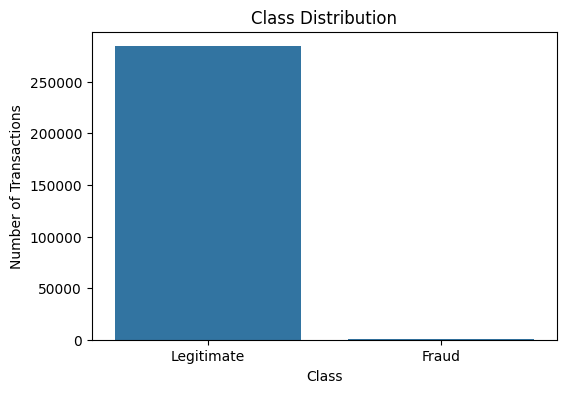

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

## Class Imbalance

The dataset contains 284,807 transactions.

- Legitimate transactions: 284,315 (approximately 99.83%)
- Fraudulent transactions: 492 (approximately 0.17%)

This shows severe class imbalance.

Because fraudulent transactions represent only a very small portion of the dataset, accuracy alone is not sufficient for evaluating fraud detection models.

In [10]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (227845, 30)
Testing data shape: (56962, 30)


In [12]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

print("Amount feature scaled successfully!")

Amount feature scaled successfully!


In [13]:
lr_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [14]:
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression predictions completed!")

Logistic Regression predictions completed!


In [15]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.9755
Precision: 0.0609
Recall   : 0.9184
F1-Score : 0.1142


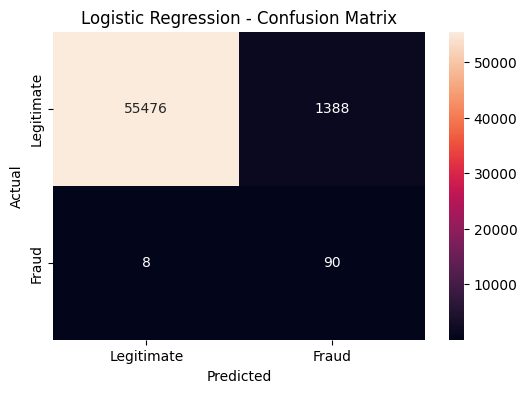

In [16]:
lr_cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [17]:
print("Logistic Regression Classification Report")
print("------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Legitimate", "Fraud"]
    )
)

Logistic Regression Classification Report
------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [19]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [20]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

Random Forest Results
---------------------
Accuracy : 0.9995
Precision: 0.9605
Recall   : 0.7449
F1-Score : 0.8391


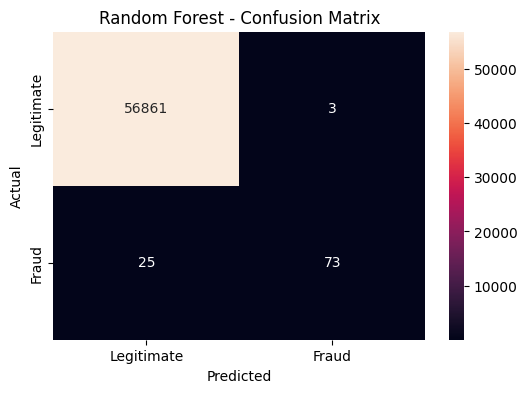

In [21]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [22]:
print("Random Forest Classification Report")
print("-----------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Legitimate", "Fraud"]
    )
)

Random Forest Classification Report
-----------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [23]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.975492,0.060893,0.918367,0.114213
1,Random Forest,0.999508,0.960526,0.744898,0.839080


In [24]:
results_percentage = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_percentage[column] *= 100

results_percentage = results_percentage.round(2)

results_percentage.style.hide(axis="index")

Model,Accuracy,Precision,Recall,F1-Score
Logistic Regression,97.550000,6.090000,91.840000,11.420000
Random Forest,99.950000,96.050000,74.490000,83.910000


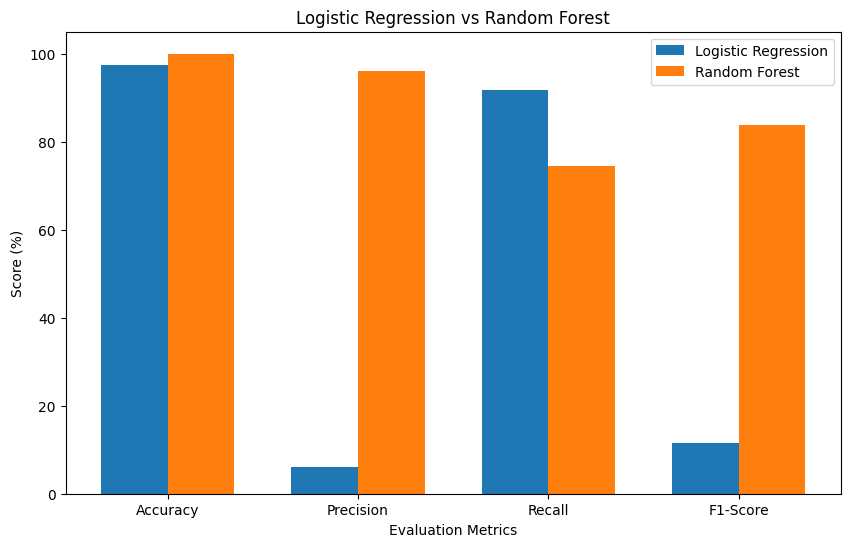

In [25]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    results_percentage.loc[0, metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width / 2,
    results_percentage.loc[1, metrics],
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.xlabel("Evaluation Metrics")
plt.title("Logistic Regression vs Random Forest")
plt.ylim(0, 105)
plt.legend()

plt.show()

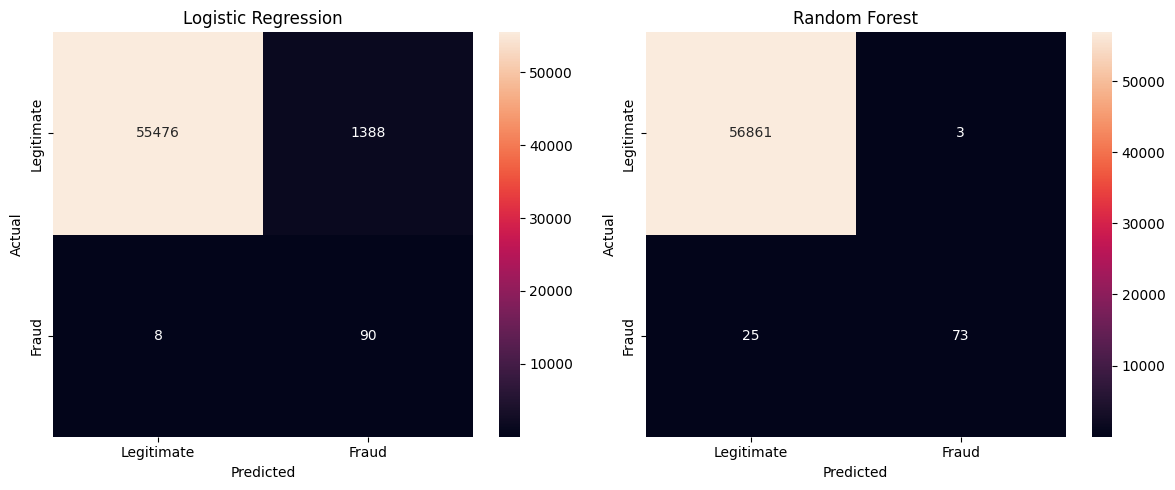

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    ax=axes[0],
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    ax=axes[1],
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [27]:
lr_tn, lr_fp, lr_fn, lr_tp = lr_cm.ravel()
rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "True Negatives": [lr_tn, rf_tn],
    "False Positives": [lr_fp, rf_fp],
    "False Negatives": [lr_fn, rf_fn],
    "True Positives": [lr_tp, rf_tp]
})

comparison.style.hide(axis="index")

Model,True Negatives,False Positives,False Negatives,True Positives
Logistic Regression,55476,1388,8,90
Random Forest,56861,3,25,73


# Final Interpretation

The dataset is highly imbalanced, with fraudulent transactions representing only approximately 0.17% of all transactions.

Logistic Regression achieved an accuracy of approximately 97.55%, precision of 6.09%, recall of 91.84%, and F1-score of 11.42%.

Random Forest achieved an accuracy of approximately 99.95%, precision of 96.05%, recall of 74.49%, and F1-score of 83.91%.

Logistic Regression achieved higher recall, meaning it detected a larger proportion of the actual fraudulent transactions. However, it produced a much larger number of false positive alerts.

Random Forest produced significantly fewer false positives and achieved higher precision and F1-score. However, its recall was lower, meaning it missed more fraudulent transactions than Logistic Regression.

These results demonstrate that fraud detection involves a trade-off between detecting more fraudulent transactions and reducing false alarms.

Therefore, accuracy alone should not be used to evaluate models on highly imbalanced datasets. Precision, recall, F1-score, and the confusion matrix provide a more complete understanding of model performance.

# Conclusion

In this project, we developed and evaluated two Machine Learning models for credit card fraud detection: Logistic Regression and Random Forest.

The dataset contained severe class imbalance, making traditional accuracy-based evaluation insufficient.

Both models were trained using the same train-test split and preprocessing procedure. Their performance was evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

The results demonstrate that different models provide different trade-offs between fraud detection and false alerts.

This project highlights the importance of selecting appropriate evaluation metrics when working with highly imbalanced classification problems.